# Series de Taylor

Implementación y aplicación de **polinomios de Taylor** para aproximar funciones alrededor de un punto conocido.

Este notebook presenta el fundamento matemático del método, una implementación simbólica en Python y varias aplicaciones que permiten analizar la precisión de las aproximaciones, el error de truncamiento y el uso de los polinomios para aproximar valores, integrales y derivadas.

### Objetivos

- Comprender la construcción de un polinomio de Taylor alrededor de un punto $x_0$.
- Implementar el cálculo de polinomios de Taylor utilizando derivadas simbólicas.
- Comparar una función con polinomios de diferentes grados.
- Calcular errores absolutos y relativos.
- Estimar una cota del error de truncamiento.
- Utilizar un polinomio de Taylor para aproximar integrales y derivadas.

**Tecnologías:** Python · NumPy · SymPy · Matplotlib · Pandas

## 1. Fundamento del método

Sea una función $f$ suficientemente derivable alrededor de un punto $x_0$. Su polinomio de Taylor de grado $n$ se define como:

$$
P_n(x)=\sum_{k=0}^{n}\frac{f^{(k)}(x_0)}{k!}(x-x_0)^k
$$

o, de forma desarrollada:

$$
P_n(x)=
f(x_0)
+f'(x_0)(x-x_0)
+\frac{f''(x_0)}{2!}(x-x_0)^2
+\cdots
+\frac{f^{(n)}(x_0)}{n!}(x-x_0)^n
$$

El polinomio busca reproducir localmente el comportamiento de la función alrededor de $x_0$. En general, la aproximación tiende a ser mejor cerca del punto de expansión y puede deteriorarse cuando el valor evaluado se aleja de él.

### Errores de aproximación

Para comparar el valor real $f(x)$ con una aproximación $P_n(x)$ se utilizan:

**Error absoluto**

$$
E_a=\left|f(x)-P_n(x)\right|
$$

**Error relativo**

$$
E_r=\frac{|f(x)-P_n(x)|}{|f(x)|}
$$

siempre que $f(x)\neq0$.

### Resto de Taylor

El error de truncamiento puede expresarse mediante el resto de Lagrange:

$$
R_n(x)=
\frac{f^{(n+1)}(\xi)}{(n+1)!}(x-x_0)^{n+1}
$$

para algún $\xi$ entre $x_0$ y $x$.

Si se conoce una cota $M$ para $|f^{(n+1)}(x)|$ en ese intervalo, entonces:

$$
|R_n(x)|
\leq
\frac{M}{(n+1)!}|x-x_0|^{n+1}
$$

## 2. Implementación

La función `serie_taylor` calcula simbólicamente las derivadas de la función, las evalúa en el punto de expansión y construye el polinomio término a término.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp
from math import factorial

x = sp.Symbol('x')

def serie_taylor(f,x0,n):
  P=0
  for k in range(n+1):
    # Función, variable con respecto a la cual voy a derivar, orden de la derivada
    df=sp.diff(f, x, k)
    # Evalúa la derivada en el punto x = x0
    df=df.evalf(subs={x:x0})
    # Añade al polinomio el término de orden k de la serie de Taylor
    P+=df*(x-x0)**k/factorial(k)

  return P

## 3. Aplicación 1 — Aproximación de $\ln(x^2+1)$

Se considera la función:

$$
f(x)=\ln(x^2+1)
$$

alrededor de:

$$
x_0=0
$$

Se comparan polinomios de Taylor de grados $2$, $4$ y $7$, evaluando la aproximación en $x=1$ y calculando sus errores.

Debido a la simetría de la función alrededor de cero, las derivadas impares evaluadas en $x_0=0$ son nulas. Por esta razón, algunos grados consecutivos pueden producir el mismo polinomio efectivo.

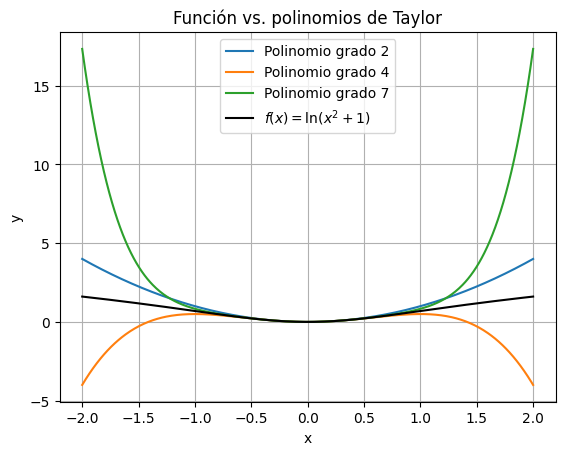

,Grado,x,f(x),P(x),Error absoluto,Error relativo
0,2,1,0.693147,1.000000,0.306853,0.442695
1,4,1,0.693147,0.500000,0.193147,0.278652
2,7,1,0.693147,0.833333,0.140186,0.202246


In [2]:
f = sp.log(x**2 + 1)
ux = np.linspace(-2, 2, 500)

F = sp.lambdify(x, f)
resultados = []

for grado in [2, 4, 7]:
  P_simbolico = serie_taylor(f, 0, grado)
  P = sp.lambdify(x, P_simbolico)

  valor_real = F(1)
  valor_aprox = P(1)
  error_abs = abs(valor_real - valor_aprox)
  error_rel = error_abs / abs(valor_real)

  resultados.append([grado, 1, valor_real, valor_aprox, error_abs, error_rel])

  plt.plot(ux, P(ux), label=f'Polinomio grado {grado}')

plt.plot(ux, F(ux), 'k', label=r'$f(x)=\ln(x^2+1)$')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Función vs. polinomios de Taylor')
plt.legend()
plt.grid(True)
plt.show()

pd.DataFrame(
    resultados,
    columns=['Grado', 'x', 'f(x)', 'P(x)', 'Error absoluto', 'Error relativo']
)

### Análisis

En $x=1$ los errores disminuyen al incorporar más términos de la serie:

- Grado 2: $P(1)=1$
- Grado 4: $P(1)=0.5$
- Grado 7: $P(1)\approx0.8333$

El valor real es:

$$
f(1)=\ln(2)\approx0.6931
$$

La gráfica permite observar que los polinomios presentan una mejor aproximación cerca del punto de expansión $x_0=0$ y que la diferencia aumenta al alejarse de ese entorno.

## 4. Aplicación 2 — $e^{2x}\sin(x)$

Se considera:

$$
f(x)=e^{2x}\sin(x)
$$

alrededor de:

$$
x_0=0
$$

El ejercicio utiliza el polinomio de Taylor de grado $3$ para:

- aproximar la función en $x=1$ y $x=4.5$;
- calcular el error absoluto y relativo;
- estimar una cota del error de truncamiento en $x=1$;
- comparar gráficamente polinomios de diferentes grados;
- aproximar $\int_0^1 f(x)\,dx$;
- aproximar $f'(1)$.

También se comparan polinomios de grados $1$, $2$, $3$, $4$ y $6$ en $x=1$.

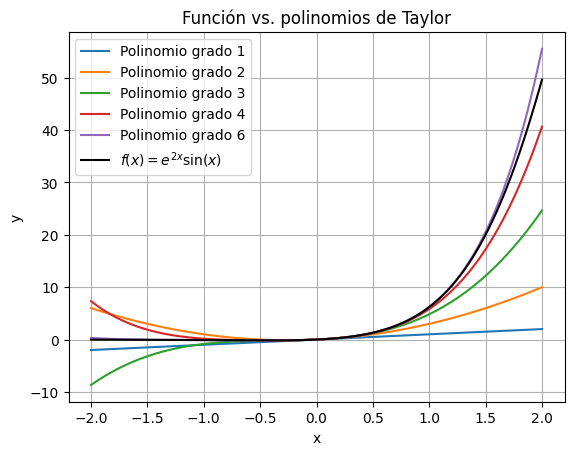

Polinomio de Taylor de grado 3:


Eq(P_3(x), 1.83333333333333*x**3 + 2.0*x**2 + 1.0*x)


Evaluación del polinomio de grado 3:


,x,f(x),P3(x),Error absoluto,Error relativo
0,1.0,6.217676,4.833333,1.384343,0.222646
1,4.5,-7921.008585,212.062500,8133.071085,1.026772


Comparación de diferentes grados en x = 1:


,Grado,x,f(x),P(x),Error absoluto,Error relativo
0,1,1,6.217676,1.000000,5.217676,0.839168
1,2,1,6.217676,3.000000,3.217676,0.517505
2,3,1,6.217676,4.833333,1.384343,0.222646
3,4,1,6.217676,5.833333,0.384343,0.061815
4,6,1,6.217676,6.236111,0.018435,0.002965



Cuarta derivada:


(-7*sin(x) + 24*cos(x))*exp(2*x)

Cota aproximada del error de Taylor en x = 1: 2.4176879834
Máximo numérico de |f⁽⁴⁾(x)| en [0,1]: 58.0245116004

Integral exacta de f(x) en [0,1]: 1.8886057153
Integral aproximada usando P3(x): 1.6250000000
Error absoluto de la integral: 0.2636057153
Error relativo de la integral: 0.1395768916

Derivada aproximada P3'(1): 10.5000000000
Derivada exacta f'(1): 16.4276766732
Error absoluto de la derivada: 5.9276766732
Error relativo de la derivada: 0.3608347541


In [3]:
f = sp.exp(2*x) * sp.sin(x)

ux = np.linspace(-2, 2, 500)
F = sp.lambdify(x, f)

resultados_grados = []

# Comparación de diferentes grados en x = 1
for grado in [1, 2, 3, 4, 6]:
  P_simbolico = serie_taylor(f, 0, grado)
  P = sp.lambdify(x, P_simbolico)

  valor_real = F(1)
  valor_aprox = P(1)
  error_abs = abs(valor_real - valor_aprox)
  error_rel = error_abs / abs(valor_real)

  resultados_grados.append(
      [grado, 1, valor_real, valor_aprox, error_abs, error_rel]
  )

  plt.plot(ux, P(ux), label=f'Polinomio grado {grado}')

plt.plot(ux, F(ux), 'k', label=r'$f(x)=e^{2x}\sin(x)$')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Función vs. polinomios de Taylor')
plt.legend()
plt.grid(True)
plt.show()

P3 = serie_taylor(f, 0, 3)

print("Polinomio de Taylor de grado 3:")
display(sp.Eq(sp.Symbol('P_3(x)'), P3))
print()

# Evaluación del polinomio de grado 3 en los puntos solicitados
P3_num = sp.lambdify(x, P3)
resultados_p3 = []

for punto in [1, 4.5]:
  valor_real = F(punto)
  valor_aprox = P3_num(punto)
  error_abs = abs(valor_real - valor_aprox)
  error_rel = error_abs / abs(valor_real)

  resultados_p3.append(
      [punto, valor_real, valor_aprox, error_abs, error_rel]
  )

print("Evaluación del polinomio de grado 3:")
display(pd.DataFrame(
    resultados_p3,
    columns=['x', 'f(x)', 'P3(x)', 'Error absoluto', 'Error relativo']
))

print("Comparación de diferentes grados en x = 1:")
display(pd.DataFrame(
    resultados_grados,
    columns=['Grado', 'x', 'f(x)', 'P(x)', 'Error absoluto', 'Error relativo']
))

# Cota del error de Taylor para P3(1)
df4 = sp.diff(f, x, 4)

x0 = 0
x_point = 1
n = 3

ux_cota = np.linspace(min(x0, x_point), max(x0, x_point), 1000)
valor_max = max(abs(sp.lambdify(x, df4)(ux_cota)))

cota = valor_max * abs((x_point - x0)**(n+1) / factorial(n+1))

print()
print("Cuarta derivada:")
display(df4)
print(f"Cota aproximada del error de Taylor en x = 1: {cota:.10f}")
print(f"Máximo numérico de |f⁽⁴⁾(x)| en [0,1]: {valor_max:.10f}")

# Aproximación de la integral
integral_exact = sp.integrate(f, (x, 0, 1))
integral_aprox = sp.integrate(P3, (x, 0, 1))

EAI = abs(integral_exact - integral_aprox)
ERI = EAI / abs(integral_exact)

print()
print(f"Integral exacta de f(x) en [0,1]: {float(integral_exact):.10f}")
print(f"Integral aproximada usando P3(x): {float(integral_aprox):.10f}")
print(f"Error absoluto de la integral: {float(EAI):.10f}")
print(f"Error relativo de la integral: {float(ERI):.10f}")

# Aproximación de f'(1)
derivada_aprox = sp.diff(P3, x)
derivada_aprox_val = derivada_aprox.subs(x, 1)

derivada_exacta = sp.diff(f, x)
derivada_exacta_val = derivada_exacta.subs(x, 1)

EAD = abs(derivada_exacta_val - derivada_aprox_val)
ERD = EAD / abs(derivada_exacta_val)

print()
print(f"Derivada aproximada P3'(1): {float(derivada_aprox_val):.10f}")
print(f"Derivada exacta f'(1): {float(derivada_exacta_val):.10f}")
print(f"Error absoluto de la derivada: {float(EAD):.10f}")
print(f"Error relativo de la derivada: {float(ERD):.10f}")

### Análisis

El polinomio de grado $3$ obtenido es:

$$
P_3(x)=x+2x^2+\frac{11}{6}x^3
$$

En $x=1$, la aproximación conserva una relación razonable con el valor real. En cambio, en $x=4.5$ el error crece de forma considerable, ya que este punto se encuentra mucho más alejado del centro de expansión $x_0=0$.

Este comportamiento destaca una característica fundamental de los polinomios de Taylor: son aproximaciones **locales** y su precisión depende tanto del grado utilizado como de la distancia al punto de expansión.

La cota de truncamiento calculada en $[0,1]$ es mayor que el error real cometido por $P_3(1)$, como debe ocurrir en una cota válida.

Además, el mismo polinomio puede utilizarse para aproximar integrales y derivadas, aunque estas operaciones también heredan el error asociado a la aproximación polinómica.

## 5. Aplicación 3 — $\frac{e^x}{x}$ alrededor de $x_0=1$

Se considera:

$$
f(x)=\frac{e^x}{x}
$$

y se construye un polinomio de Taylor de grado $7$ alrededor de:

$$
x_0=1
$$

El polinomio se utiliza para:

- aproximar $f(1.5)$;
- calcular el error absoluto y relativo;
- aproximar la integral de la función entre $1$ y $1.5$;
- comparar la integral exacta con la obtenida mediante el polinomio.

In [4]:
f = sp.exp(x) / x
F = sp.lambdify(x, f)

P7 = serie_taylor(f, 1, 7)
P7_num = sp.lambdify(x, P7)

valor_real = F(1.5)
valor_aprox = P7_num(1.5)
error_abs = abs(valor_real - valor_aprox)
error_rel = error_abs / abs(valor_real)

print("Polinomio de grado 7 alrededor de x0 = 1:")
display(sp.Eq(sp.Symbol('P_7(x)'), P7))
print()

integral_exact = sp.integrate(f, (x, 1, 1.5))
integral_aprox = sp.integrate(P7, (x, 1, 1.5))

EAI = abs(integral_exact - integral_aprox)
ERI = EAI / abs(integral_exact)

print(f"Integral exacta de f(x) en [1,1.5]: {float(integral_exact):.10f}")
print(f"Integral aproximada usando P7(x): {float(integral_aprox):.10f}")
print(f"Error absoluto de la integral: {float(EAI):.10f}")
print(f"Error relativo de la integral: {float(ERI):.10f}")
print()

pd.DataFrame(
    [[1.5, valor_real, valor_aprox, error_abs, error_rel]],
    columns=['x', 'f(x)', 'P7(x)', 'Error absoluto', 'Error relativo']
)

Polinomio de grado 7 alrededor de x0 = 1:


Eq(P_7(x), 0.e-125*x - 0.999939386897435*(x - 1)**7 + 1.00047872853007*(x - 1)**6 - 0.99670333710165*(x - 1)**5 + 1.01935568567214*(x - 1)**4 - 0.906093942819682*(x - 1)**3 + 1.35914091422952*(x - 1)**2 + 2.71828182845905)

Integral exacta de f(x) en [1,1.5]: 1.4061676328
Integral aproximada usando P7(x): 1.4060178133
Error absoluto de la integral: 0.0001498195
Error relativo de la integral: 0.0001065445



,x,f(x),P7(x),Error absoluto,Error relativo
0,1.5,2.987793,2.985189,0.002604,0.000872


### Análisis

La aproximación de grado $7$ alrededor de $x_0=1$ produce un error pequeño al evaluar en $x=1.5$.

También se obtiene una buena aproximación de la integral en el intervalo $[1,1.5]$, lo cual es coherente con el hecho de que el intervalo permanece relativamente cerca del punto de expansión.

El resultado muestra cómo un polinomio de Taylor puede utilizarse no solo para evaluar una función, sino también como una representación aproximada que puede integrarse de forma directa.

## 6. Conclusiones

A partir de las aplicaciones desarrolladas se puede concluir que:

- Los polinomios de Taylor permiten aproximar funciones mediante polinomios construidos a partir de sus derivadas.
- El punto de expansión influye directamente en la calidad de la aproximación.
- En general, la precisión disminuye cuando el valor evaluado se aleja del punto alrededor del cual se construyó el polinomio.
- Aumentar el grado puede mejorar la aproximación, aunque el comportamiento también depende de la función y de la región analizada.
- Los errores absoluto y relativo permiten cuantificar la diferencia entre la función original y el polinomio.
- El resto de Taylor proporciona una forma de estimar una cota del error de truncamiento.
- Los polinomios obtenidos pueden utilizarse para aproximar valores de funciones, integrales y derivadas.